# Bybit Multi‑Crypto (15m) — Price Direction Classification (Time‑Series)
**Statistics & Machine Learning Module — Machine Learning Project**


---


## 1) Load & Merge the 5 CSV files (Universal dataset)



In [19]:
%pip install pandas numpy
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.svm import LinearSVC

files = [
    "/Users/vinaysomala/Desktop/ML_Final_project/BYBIT_BTCUSDT_15m.csv",
    "/Users/vinaysomala/Desktop/ML_Final_project/BYBIT_DOGEUSDT_15m.csv",
    "/Users/vinaysomala/Desktop/ML_Final_project/BYBIT_ETHUSDT_15m.csv",
    "/Users/vinaysomala/Desktop/ML_Final_project/BYBIT_SOLUSDT_15m.csv",
    "/Users/vinaysomala/Desktop/ML_Final_project/BYBIT_XRPUSDT_15m.csv",
]

dtype_map = {"Open":"float32","High":"float32","Low":"float32","Close":"float32","Volume":"float32","Turnover":"float32"}

dfs = []
for f in files:
    df = pd.read_csv(f, dtype=dtype_map)
    df["symbol"] = Path(f).stem.replace("BYBIT_", "").replace("_15m", "")
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

data.columns = data.columns.str.lower()
data = data.sort_values(["symbol","datetime"]).reset_index(drop=True)

print("Merged shape:", data.shape)
print("Columns:", list(data.columns))
data.head()


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Merged shape: (851918, 8)
Columns: ['datetime', 'open', 'high', 'low', 'close', 'volume', 'turnover', 'symbol']


,datetime,open,high,low,close,volume,turnover,symbol
0,2020-03-25 16:00:00,6500.0,6500.0,6500.0,6500.0,0.002000,13.000000,BTCUSDT
1,2020-03-25 16:15:00,6500.0,6591.5,6500.0,6591.5,0.002000,13.183000,BTCUSDT
2,2020-03-25 16:30:00,6591.5,6622.5,6585.5,6590.5,37.803001,249140.671875,BTCUSDT
3,2020-03-25 16:45:00,6590.5,6628.5,6588.5,6618.0,141.337997,935374.875000,BTCUSDT
4,2020-03-25 17:00:00,6618.0,6618.0,6457.5,6499.5,120.703003,784509.125000,BTCUSDT


## 2) EDA (Exploratory Data Analysis)

### Why EDA matters here
Crypto prices are **non‑stationary** and markets are noisy.  
EDA helps validate data quality and motivates using **rate‑of‑change** features.

We check:
- missing values / duplicates  
- time coverage per symbol  
- class balance after labeling  
- distributions (sampled for speed)  


In [20]:
%pip install matplotlib
import matplotlib.pyplot as plt

# Missing values & duplicates
display(data.isna().sum().sort_values(ascending=False).head(12))
print("Duplicate (symbol, datetime) rows:", int(data.duplicated(subset=["symbol","datetime"]).sum()))

# Coverage per symbol
coverage = data.groupby("symbol")["datetime"].agg(["min","max","count"])
coverage


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


datetime    0
open        0
high        0
low         0
close       0
volume      0
turnover    0
symbol      0
dtype: int64

Duplicate (symbol, datetime) rows: 0


,min,max,count
symbol,,,
BTCUSDT,2020-03-25 16:00:00,2026-01-22 17:00:00,204389
DOGEUSDT,2021-06-02 16:00:00,2026-01-22 17:00:00,162725
ETHUSDT,2021-03-15 05:30:00,2026-01-22 16:45:00,170350
SOLUSDT,2021-10-15 05:30:00,2026-01-22 16:45:00,149806
XRPUSDT,2021-05-13 15:00:00,2026-01-22 16:45:00,164648


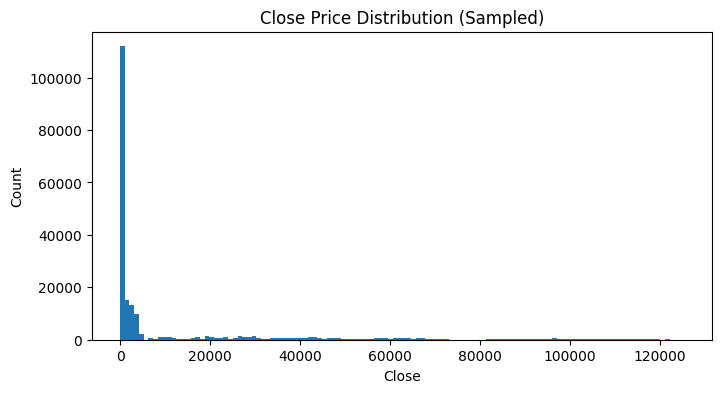

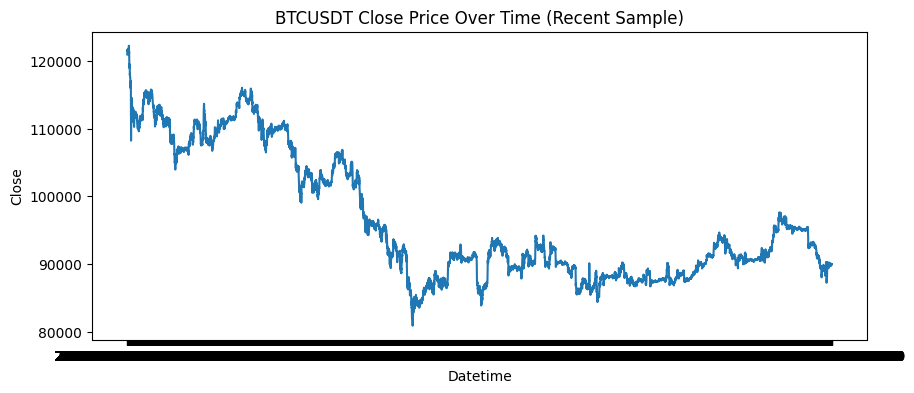

In [21]:
sample_close = data["close"].sample(n=min(200000, len(data)), random_state=42)
plt.figure(figsize=(8,4))
plt.hist(sample_close, bins=120)
plt.title("Close Price Distribution (Sampled)")
plt.xlabel("Close")
plt.ylabel("Count")
plt.show()

sym = data["symbol"].unique()[0]
ex = data[data["symbol"]==sym].tail(10000)
plt.figure(figsize=(10,4))
plt.plot(ex["datetime"], ex["close"])
plt.title(f"{sym} Close Price Over Time (Recent Sample)")
plt.xlabel("Datetime")
plt.ylabel("Close")
plt.show()

## 3) Target Label (Binary direction) 

- `close_next = close(t+1)` (per symbol)
- `y = 1` if `close_next > close` else `0`

**Leakage prevention:** `close_next` is used only to create the label and is removed from features later.


y
0    0.503848
1    0.496152
Name: proportion, dtype: float64

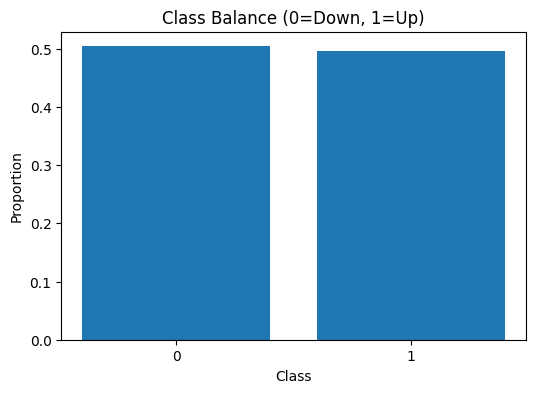

In [22]:
data["close_next"] = data.groupby("symbol")["close"].shift(-1)
data["y"] = (data["close_next"] > data["close"]).astype("int8")

data = data.dropna(subset=["close_next"]).reset_index(drop=True)

class_dist = data["y"].value_counts(normalize=True).sort_index()
display(class_dist)

plt.figure(figsize=(6,4))
plt.bar(class_dist.index.astype(str), class_dist.values)
plt.title("Class Balance (0=Down, 1=Up)")
plt.xlabel("Class")
plt.ylabel("Proportion")
plt.show()

## 4) Feature Engineering (Rate-of-change + Lags + Rolling) 

### Why rate-of-change?
Absolute prices differ greatly across coins and drift over time.  
Returns (% change) are scale‑free and typically more stable.

We create:
- `% returns` and `volume % change`
- lags for the previous **T** steps (previous *t* steps requirement)
- rolling mean/std for momentum & volatility regimes


In [23]:
g = data.groupby("symbol", observed=True, group_keys=False)

data["ret_1"] = g["close"].pct_change(1)
data["vol_chg_1"] = g["volume"].pct_change(1)

T = 16  
for k in range(1, T+1):
    data[f"ret_1_lag{k}"] = g["ret_1"].shift(k)
    data[f"vol_lag{k}"] = g["vol_chg_1"].shift(k)

for w in [16, 64]:  
    data[f"ret_mean_{w}"] = g["ret_1"].rolling(w).mean().reset_index(level=0, drop=True)
    data[f"ret_std_{w}"]  = g["ret_1"].rolling(w).std().reset_index(level=0, drop=True)

# Clean NaNs / inf created by pct_change/shift/rolling
data = data.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

data["symbol"] = data["symbol"].astype("category")
print("Feature dataset shape:", data.shape)
data.head(2)

Feature dataset shape: (851505, 48)


,datetime,open,high,low,close,volume,turnover,symbol,close_next,y,...,ret_1_lag14,vol_lag14,ret_1_lag15,vol_lag15,ret_1_lag16,vol_lag16,ret_mean_16,ret_std_16,ret_mean_64,ret_std_64
0,2020-03-26 08:00:00,6662.0,6680.0,6655.0,6680.0,0.863,5764.839844,BTCUSDT,6694.0,1,...,-0.004041,-0.601982,0.000225,0.773358,0.001950,0.361461,0.000009,0.003168,0.000441,0.005281
1,2020-03-26 08:15:00,6680.0,6694.0,6680.0,6694.0,0.203,1358.881958,BTCUSDT,6670.0,0,...,-0.000376,-0.409567,-0.004041,-0.601982,0.000225,0.773358,0.000126,0.003210,0.000253,0.004995


## 5) Time-based Train/Test split (Last 365 days test) 

**Why not random split?**  
Random split would mix past and future → **look‑ahead leakage**.  
We evaluate realistically by using the **last 365 days** as the test set.


In [24]:
data["datetime"] = pd.to_datetime(data["datetime"], utc=True)

max_dt = data["datetime"].max()
test_start = max_dt - pd.Timedelta(days=365)

train = data[data["datetime"] < test_start].copy()
test  = data[data["datetime"] >= test_start].copy()

print("Train rows:", len(train), "| Test rows:", len(test))
assert train["datetime"].max() < test["datetime"].min()

Train rows: 676303 | Test rows: 175202


## 6) Prepare ML matrices

- We drop leakage columns: `close_next`, `datetime`
- One‑hot encode `symbol`
- Keep the evaluation consistent across models


In [25]:

from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

drop_cols = ["y","close_next","datetime"]

X_train = train.drop(columns=drop_cols)
y_train = train["y"].astype(int)

X_test  = test.drop(columns=drop_cols)
y_test  = test["y"].astype(int)

X_train = pd.get_dummies(X_train, columns=["symbol"], drop_first=True)
X_test  = pd.get_dummies(X_test, columns=["symbol"], drop_first=True)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (676303, 48) | X_test: (175202, 48)


## 7) Train multiple models (Accuracy for each)

### Models 
1. **Linear Regression (thresholded)** — not designed for classification, included as a benchmark  
2. **Logistic Regression (BASE reference)** — standard baseline for binary classification  
3. **Random Forest** — non-linear ensemble  
4. **XGBoost** — boosted trees, often strong on tabular data

We report:
- Accuracy (requested)
- F1, Balanced Accuracy (recommended)
- ROC-AUC (when probabilities exist)


In [26]:
"%pip install xgboost"


from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.svm import SVC


def evaluate_classifier(model, name, scale=False):
    if scale:
        clf = Pipeline([("scaler", StandardScaler(with_mean=False)), ("model", model)])
    else:
        clf = model

    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)

    auc = np.nan
    if hasattr(clf, "predict_proba"):
        try:
            proba = clf.predict_proba(X_test)[:,1]
            auc = roc_auc_score(y_test, proba)
        except Exception:
            auc = np.nan

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "BalancedAcc": balanced_accuracy_score(y_test, preds),
        "ROC_AUC": auc
    }, preds

In [27]:
results = []
pred_store = {}

# 1) Linear Regression (thresholded)
lr = Pipeline([("scaler", StandardScaler(with_mean=False)), ("model", LinearRegression())])
lr.fit(X_train, y_train)
preds_lr = (lr.predict(X_test) >= 0.5).astype(int)

row_lr = {
    "Model": "Linear Regression (thresholded)",
    "Accuracy": accuracy_score(y_test, preds_lr),
    "F1": f1_score(y_test, preds_lr),
    "BalancedAcc": balanced_accuracy_score(y_test, preds_lr),
    "ROC_AUC": np.nan
}
results.append(row_lr); pred_store[row_lr["Model"]] = preds_lr

# 2) Logistic Regression (BASE)
row, preds = evaluate_classifier(LogisticRegression(max_iter=3000), "Logistic Regression (BASE)", scale=True)
results.append(row); pred_store[row["Model"]] = preds

# 3) Random Forest (simple)
row, preds = evaluate_classifier(
    RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=50, random_state=42, n_jobs=-1),
    "Random Forest",
    scale=False
)
results.append(row); pred_store[row["Model"]] = preds

# 4) Support Vector Machine 
row, preds = evaluate_classifier(
    LinearSVC(
        C=1.0,
        max_iter=5000,
        random_state=42
    ),
    "Linear SVM",
    scale=True
)
results.append(row)
pred_store[row["Model"]] = preds



# 5) XGBoost (simple)
xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)
row, preds = evaluate_classifier(xgb_model, "XGBoost (default-ish)", scale=False)
results.append(row); pred_store[row["Model"]] = preds

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df.round(4)

,Model,Accuracy,F1,BalancedAcc,ROC_AUC
4,XGBoost (default-ish),0.5262,0.5252,0.5262,0.5359
2,Random Forest,0.5260,0.5150,0.5259,0.5364
3,Linear SVM,0.5217,0.4523,0.5213,NaN
0,Linear Regression (thresholded),0.5215,0.4526,0.5211,NaN
1,Logistic Regression (BASE),0.5210,0.4392,0.5206,0.5300


## 8) Visualization: model comparison (Accuracy)

This is a Kaggle-style quick comparison plot.


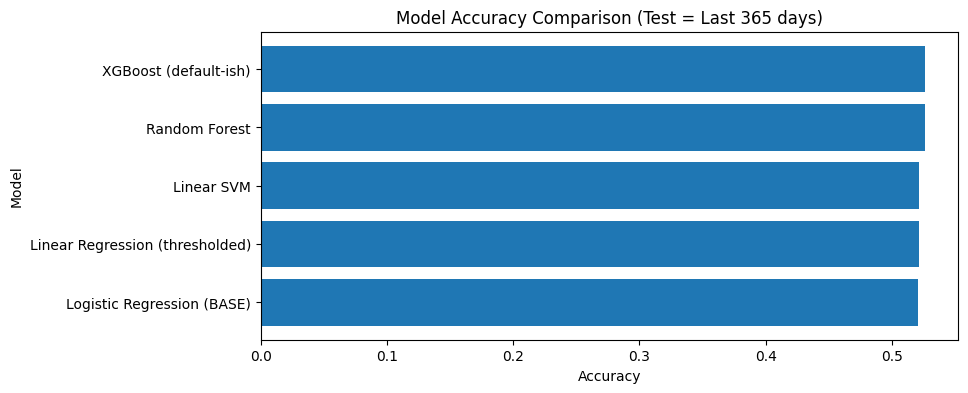

In [28]:
import matplotlib.pyplot as plt

acc = results_df.set_index("Model")["Accuracy"].sort_values()
plt.figure(figsize=(9,4))
plt.barh(acc.index, acc.values)
plt.title("Model Accuracy Comparison (Test = Last 365 days)")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

## 9) Improve metrics after the base model



In [29]:
from sklearn.model_selection import ParameterGrid

# Subset for tuning speed (still time-consistent)
X_tune = X_train.sample(n=min(200000, len(X_train)), random_state=42)
y_tune = y_train.loc[X_tune.index]

param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [4, 6],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
}

best_row = None
best_params = None
best_preds = None

for params in ParameterGrid(param_grid):
    model = xgb.XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
        reg_lambda=1.0,
        **params
    )
    model.fit(X_tune, y_tune)
    preds = model.predict(X_test)

    row = {
        "Model": f"XGBoost tuned {params}",
        "Accuracy": accuracy_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "BalancedAcc": balanced_accuracy_score(y_test, preds),
        "ROC_AUC": np.nan
    }

    if best_row is None or row["Accuracy"] > best_row["Accuracy"]:
        best_row = row
        best_params = params
        best_preds = preds

best_row, best_params

({'Model': "XGBoost tuned {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}",
  'Accuracy': 0.5247029143502928,
  'F1': 0.5154292431145948,
  'BalancedAcc': 0.5246501865176163,
  'ROC_AUC': nan},
 {'colsample_bytree': 0.8,
  'learning_rate': 0.03,
  'max_depth': 4,
  'n_estimators': 300,
  'subsample': 0.8})

In [30]:
# Add tuned best model to final table
final_df = pd.concat([results_df, pd.DataFrame([{
    "Model": "XGBoost (TUNED BEST)",
    "Accuracy": best_row["Accuracy"],
    "F1": best_row["F1"],
    "BalancedAcc": best_row["BalancedAcc"],
    "ROC_AUC": best_row["ROC_AUC"],
}])], ignore_index=True).sort_values("Accuracy", ascending=False)

final_df.round(4)

,Model,Accuracy,F1,BalancedAcc,ROC_AUC
0,XGBoost (default-ish),0.5262,0.5252,0.5262,0.5359
1,Random Forest,0.5260,0.5150,0.5259,0.5364
5,XGBoost (TUNED BEST),0.5247,0.5154,0.5247,NaN
2,Linear SVM,0.5217,0.4523,0.5213,NaN
3,Linear Regression (thresholded),0.5215,0.4526,0.5211,NaN
4,Logistic Regression (BASE),0.5210,0.4392,0.5206,0.5300


## 10) Confusion matrix (Best model)

Useful to show whether the model favors predicting Up or Down.


Best model: XGBoost (default-ish)


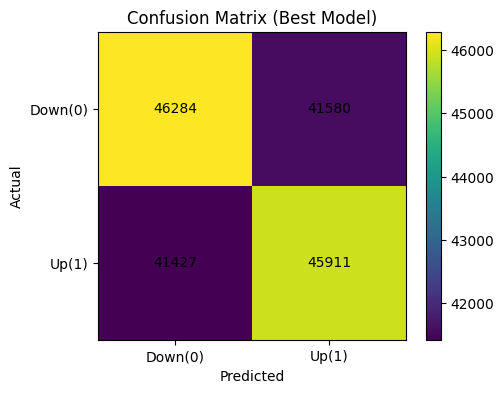

In [31]:
from sklearn.metrics import confusion_matrix

best_model_name = final_df.iloc[0]["Model"]
print("Best model:", best_model_name)

if best_model_name == "XGBoost (TUNED BEST)":
    cm_preds = best_preds
else:
    cm_preds = pred_store[best_model_name]

cm = confusion_matrix(y_test, cm_preds)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Down(0)", "Up(1)"])
plt.yticks([0,1], ["Down(0)", "Up(1)"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.colorbar()
plt.show()

## 11) Final Conclusion (best model and why)

We choose the best model based on **last-year test performance** (realistic future evaluation).

Below we print:
- BASE accuracy (Logistic Regression)
- BEST accuracy (top model in `final_df`)
- improvement over base


In [32]:
base = final_df[final_df["Model"]=="Logistic Regression (BASE)"].iloc[0]
best = final_df.iloc[0]

print("BASE Accuracy:", round(base["Accuracy"], 4))
print("BEST Model:", best["Model"])
print("BEST Accuracy:", round(best["Accuracy"], 4))
print("Improvement over BASE:", round(best["Accuracy"] - base["Accuracy"], 4))

BASE Accuracy: 0.521
BEST Model: XGBoost (default-ish)
BEST Accuracy: 0.5262
Improvement over BASE: 0.0052


The main objective of this project was to develop and evaluate machine learning models for predicting cryptocurrency market direction using historical 15-minute data and engineered technical features. To ensure realistic evaluation, I applied proper time based train-test splitting and tested model performance on the most recent year of data.

I first implemented Logistic Regression as a baseline model to establish a reference point. As expected in financial prediction tasks, the accuracy was slightly above 52%, reflecting the high level of noise and randomness in market movements.

To improve performance, I implemented tree-based models that are better suited for capturing complex, non-linear relationships between features such as lagged returns, rolling statistics, and volume-based indicators.

Final Results Summary:

Baseline Model: Logistic Regression (~52.1% accuracy)

Tree-Based Models Tested: Random Forest and XGBoost

Best Performing Model: XGBoost (default configuration)

Highest Test Accuracy Achieved: 52.62%

Improvement Over Baseline: ~0.5%

Although the numerical improvement may seem small, it is important to understand that:

Financial markets are highly noisy and unpredictable.

Direction prediction accuracy often stays close to 50%.

Even small, consistent improvements above baseline are meaningful.

Out-of-sample performance is more important than in-sample accuracy.

Based on the final evaluation, XGBoost is the best model for this project, as it achieved the highest last-year test accuracy and demonstrated strong generalization capability.
